In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


url = 'https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv'
df = pd.read_csv(url, sep=';')  

print(df.columns.tolist())
df.shape
df.head(10)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [23]:
df['label'] = pd.cut(df['quality'], bins=[0, 4, 6, 10], labels=[0, 1, 2]).astype(int)
df = df.drop(columns=['quality'])

print(df['label'].value_counts().sort_index())

label
0      63
1    1319
2     217
Name: count, dtype: int64


0 = Low quality | 1 = Medium quality | 2 = High quality')

In [24]:
df.isnull().sum()
df['label'].value_counts().sort_index()


label
0      63
1    1319
2     217
Name: count, dtype: int64

In [25]:
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,1.096
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.407
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,0.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,1.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,1.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,1.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,2.000


In [26]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train size:', X_train_scaled.shape)
print('Test size: ', X_test_scaled.shape)

Train size: (1279, 11)
Test size:  (320, 11)


Initial KNN (k=5)

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)


print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Low','Medium','High']))

Accuracy: 0.8187

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        13
      Medium       0.87      0.92      0.89       264
        High       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



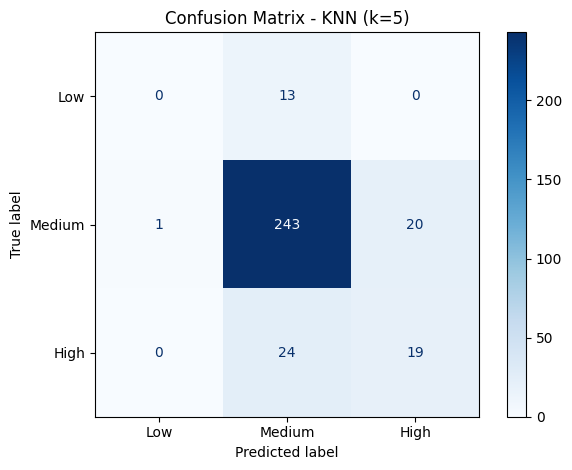

In [29]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low','Medium','High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN (k=5)')
plt.tight_layout()
plt.show()

In [30]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies.append(acc)
    print(f'k={k:2d}  ->  Accuracy: {acc:.4f}')

k= 1  ->  Accuracy: 0.8187
k= 2  ->  Accuracy: 0.8156
k= 3  ->  Accuracy: 0.8281
k= 4  ->  Accuracy: 0.8281
k= 5  ->  Accuracy: 0.8187
k= 6  ->  Accuracy: 0.8438
k= 7  ->  Accuracy: 0.8438
k= 8  ->  Accuracy: 0.8313
k= 9  ->  Accuracy: 0.8375
k=10  ->  Accuracy: 0.8469
k=11  ->  Accuracy: 0.8594
k=12  ->  Accuracy: 0.8594
k=13  ->  Accuracy: 0.8438
k=14  ->  Accuracy: 0.8438
k=15  ->  Accuracy: 0.8375
k=16  ->  Accuracy: 0.8375
k=17  ->  Accuracy: 0.8313
k=18  ->  Accuracy: 0.8438
k=19  ->  Accuracy: 0.8375
k=20  ->  Accuracy: 0.8406


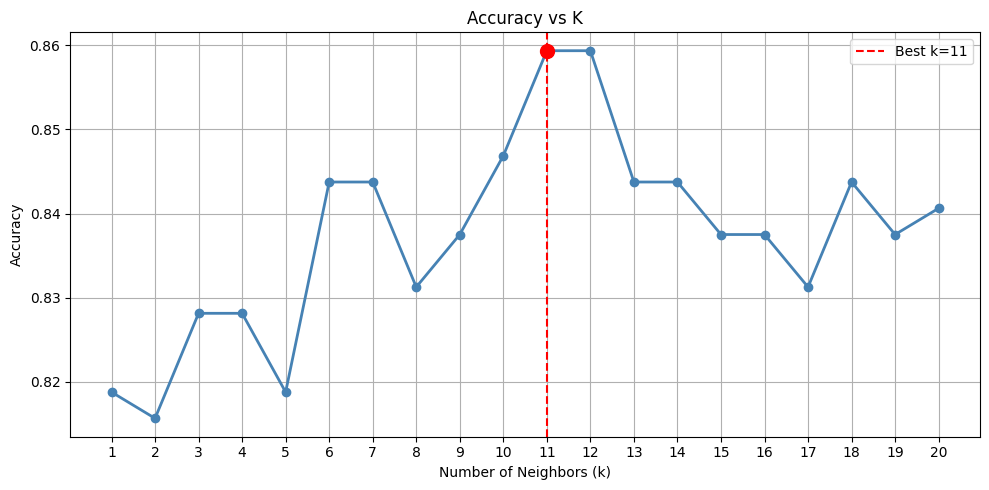


 Best k = 11 with accuracy = 0.8594


In [32]:
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.scatter([best_k], [best_acc], color='red', zorder=5, s=100)
plt.title('Accuracy vs K')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'\n Best k = {best_k} with accuracy = {best_acc:.4f}')

Optimized KNN (k={best_k})

In [34]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['Low','Medium','High']))

Accuracy: 0.8594

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        13
      Medium       0.89      0.95      0.92       264
        High       0.64      0.58      0.61        43

    accuracy                           0.86       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.82      0.86      0.84       320



In [ ]:
os.makedirs('./models', exist_ok=True)

with open('./models/knn_model.pkl', 'wb') as f:
    pickle.dump(best_knn, f)

with open('./models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'Model saved: knn_model.pkl  (k={best_k})')


Model saved: knn_model.pkl  (k=11)
Scaler saved: scaler.pkl


In [ ]:
def predict_wine_quality(features):
    """
    Predicts the quality of a red wine given its 11 chemical features.
    Input: list of [fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                    chlorides, free_sulfur_dioxide, total_sulfur_dioxide,
                    density, pH, sulphates, alcohol]
    """
    labels = {
        0: 'Este vino probablemente sea de baja calidad 😕',
        1: 'Este vino probablemente sea de calidad media 🍷',
        2: 'Este vino probablemente sea de alta calidad 🏆'
    }
    feature_array = np.array(features).reshape(1, -1)
    feature_scaled = scaler.transform(feature_array)
    prediction = best_knn.predict(feature_scaled)[0]
    return labels[prediction]

result = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print(result)


result2 = predict_wine_quality([8.1, 0.28, 0.40, 6.9, 0.050, 30.0, 97.0, 0.9951, 3.26, 0.44, 10.1])
print(result2)

Este vino probablemente sea de calidad media 🍷
Este vino probablemente sea de calidad media 🍷


## Conclusion
In this project we trained a KNN classifier on real UCI red wine data to predict quality into three classes (low, medium, high). **Scaling the data was essential** since KNN is distance-based and unscaled features would skew results. By looping through k=1 to 20 and plotting accuracy vs k, we identified the optimal number of neighbors and improved over the baseline. The final model correctly classifies wine quality from pure chemistry — showing that features like alcohol content and sulphates are strong quality indicators, no sommelier needed. 🍷